# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: Stock Success  
Created by Lexinejazly Asuncion (017077242), Pranavi Immanni (017207554), Anika Manjesh (017808479)
Last updated: March 22, 2026   

Briefly describe your dataset: Our dataset is a combination of multiple datasets of stocks.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

## **Import and Clean Data**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tech
apple_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/apple.csv'
nvidia_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/nvidia.csv'
microsoft_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/microsoft.csv'

# Defense
lockheed_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/lockheedmartin.csv'
northrop_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/northropgrumman.csv'
boeing_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/boeing.csv.zip'

# Waste Management
waste_mgt_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wastemanagementinc.csv'
republic_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/republicservices.csv'
waste_conn_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wasteconnections.csv'



In [2]:
url_list = {
    'AAPL': apple_url,
    'NVDA': nvidia_url,
    'MSFT': microsoft_url,
    'LMT': lockheed_url,
    'NOC': northrop_url,
    'BA': boeing_url,
    'WM': waste_mgt_url,
    'RSG': republic_url,
    'WCN': waste_conn_url
}

for name, url in url_list.items():
    df = pd.read_csv(url)

    print(f"\n{name} Columns:")
    print(df.columns.tolist()) #see list of column names to find common columns


AAPL Columns:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

NVDA Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

MSFT Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

LMT Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

NOC Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

BA Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

WM Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

RSG Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

WCN Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']


In [3]:
all_frames = []

rename_map = {
    'date': 'Date',
    'price': 'Close',
    'Price': 'Close',
    'Close/Last': 'Close',
    'close': 'Close',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'volume': 'Volume',
    'Vol.': 'Volume',
    'adj_close': 'Adj Close'
}

tech_tickers = ['AAPL', 'NVDA', 'MSFT']
defense_tickers = ['LMT', 'NOC', 'BA']
waste_tickers = ['WM', 'RSG', 'WCN']

#read csv files and store data into one dataframe
for name, url in url_list.items():
    df = pd.read_csv(url,
                     na_values=["-", ""])

    df.columns = [col.strip() for col in df.columns]

    df = df.rename(columns=rename_map)

    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.date

    df['Ticker'] = name

    #create column 'Industry' that specifies the industry
    if name in tech_tickers:
        df['Industry'] = 'Tech'
    elif name in defense_tickers:
        df['Industry'] = 'Defense'
    elif name in waste_tickers:
        df['Industry'] = 'Waste Management'

    #keep only the columns that exist in almost all sets
    standard_cols = ['Industry', 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[standard_cols]

    all_frames.append(df)

#merge the dataframes into one
stocks = pd.concat(all_frames, ignore_index=True)

In [4]:
#clean 'Volume', 'Open', 'High', 'Low', and 'Close' columns
stocks['Volume'] = pd.to_numeric(stocks['Volume'].astype(str).str.replace('M', 'e6').str.replace('K', 'e3').str.replace('B', 'e9'))

numeric_cols = ['Open', 'High', 'Low', 'Close']

for col in numeric_cols:
    stocks[col] = pd.to_numeric(
        stocks[col].astype(str).str.replace('$', '').str.replace(',', ''))


In [5]:
stocks.head()

,Industry,Date,Ticker,Open,High,Low,Close,Volume
0,Tech,2025-09-26,AAPL,254.10,257.60,253.78,255.46,46080000.0
1,Tech,2025-09-25,AAPL,253.21,257.17,251.71,256.87,55200000.0
2,Tech,2025-09-24,AAPL,255.22,255.74,251.04,252.31,42300000.0
3,Tech,2025-09-23,AAPL,255.88,257.34,253.58,254.43,60280000.0
4,Tech,2025-09-22,AAPL,248.30,256.64,248.12,256.08,105520000.0


In [6]:
stocks.tail()

,Industry,Date,Ticker,Open,High,Low,Close,Volume
43022,Waste Management,2026-02-27,WCN,170.00,172.47,168.8350,172.13,1863325.0
43023,Waste Management,2026-02-26,WCN,167.93,169.92,166.2675,169.34,1708740.0
43024,Waste Management,2026-02-25,WCN,166.15,167.08,164.7500,166.60,1866603.0
43025,Waste Management,2026-02-24,WCN,163.06,166.96,163.0600,165.48,2005813.0
43026,Waste Management,2026-02-23,WCN,164.20,164.44,162.0800,163.00,1865453.0


In [7]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43027 entries, 0 to 43026
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Industry  43027 non-null  object 
 1   Date      43027 non-null  object 
 2   Ticker    43027 non-null  object 
 3   Open      43027 non-null  float64
 4   High      43027 non-null  float64
 5   Low       43027 non-null  float64
 6   Close     43027 non-null  float64
 7   Volume    43027 non-null  float64
dtypes: float64(5), object(3)
memory usage: 2.6+ MB


In [8]:
stocks.describe()

,Open,High,Low,Close,Volume
count,43027.000000,43027.000000,43027.000000,43027.000000,4.302700e+04
mean,69.690101,70.415602,68.952391,69.697948,1.460122e+08
std,103.440650,104.417062,102.428038,103.433280,3.059981e+08
min,0.060833,0.065667,0.060000,0.061417,7.290000e+04
25%,2.937500,2.980453,2.893004,2.939136,2.115156e+06
50%,27.200001,27.469999,26.950001,27.219999,1.244680e+07
75%,79.029999,79.879997,78.000000,78.924999,9.952620e+07
max,768.850000,774.000000,751.870000,768.020000,9.230856e+09


### Q1: Show the number of missing data in each column of the dataframe

In [9]:
stocks.isnull().sum()

,0
Industry,0
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Volume,0


### Q2: Show the data type for each column of the dataframe

In [10]:
stocks.dtypes

,0
Industry,object
Date,object
Ticker,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,float64


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

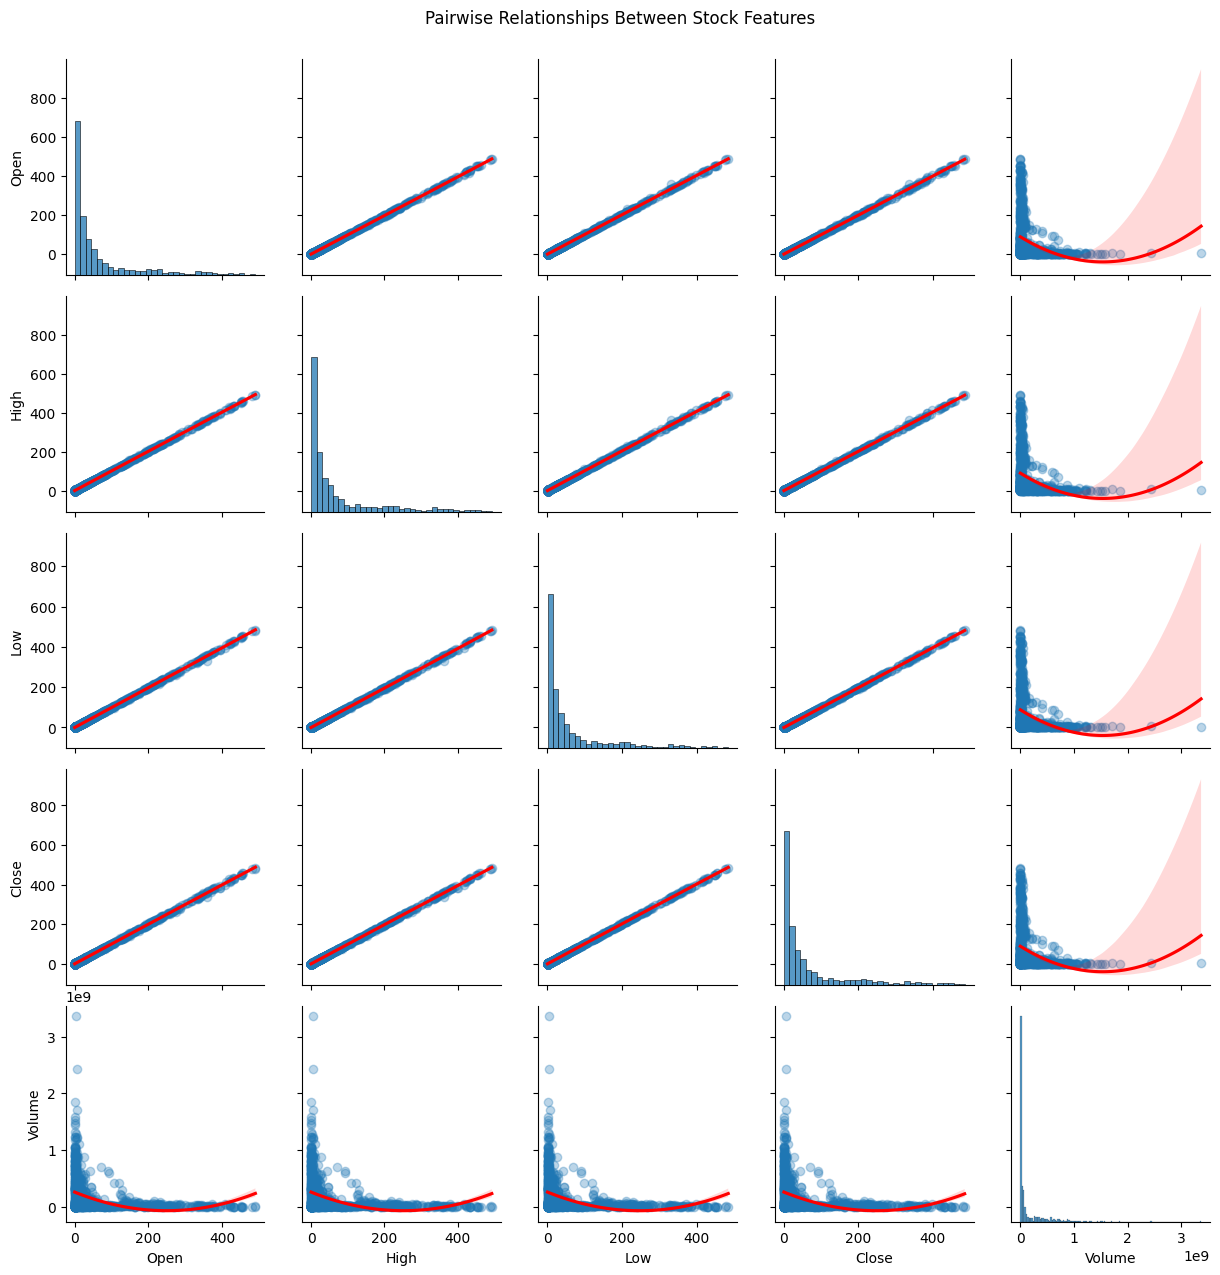

In [11]:
sample_stocks = stocks[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

sample_stocks = sample_stocks.apply(pd.to_numeric, errors='coerce')

sample_stocks = sample_stocks.dropna().sample(1000, random_state=42)

g = sns.PairGrid(sample_stocks)
g.map_diag(sns.histplot)
g.map_offdiag(
    sns.regplot,
    order=2,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

g.fig.suptitle("Pairwise Relationships Between Stock Features", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

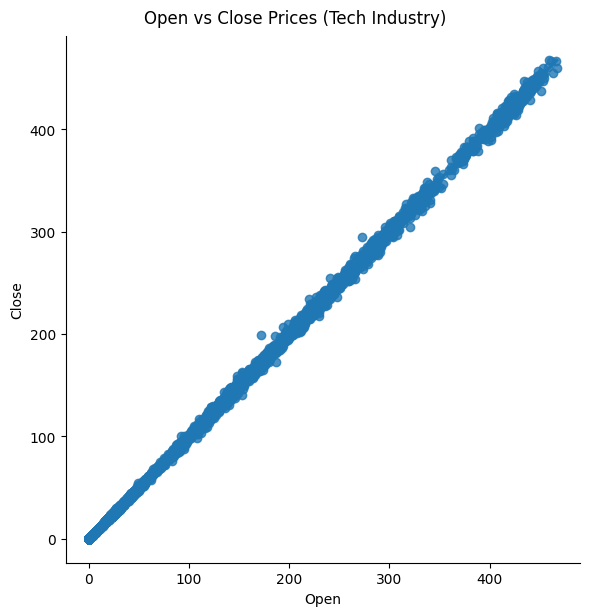

In [12]:
tech_stocks = stocks[stocks['Industry'] == 'Tech']

g = sns.lmplot(
    data=tech_stocks,
    x='Open',
    y='Close',
    height=6
)

g.fig.suptitle("Open vs Close Prices (Tech Industry)", y=1.02)
plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

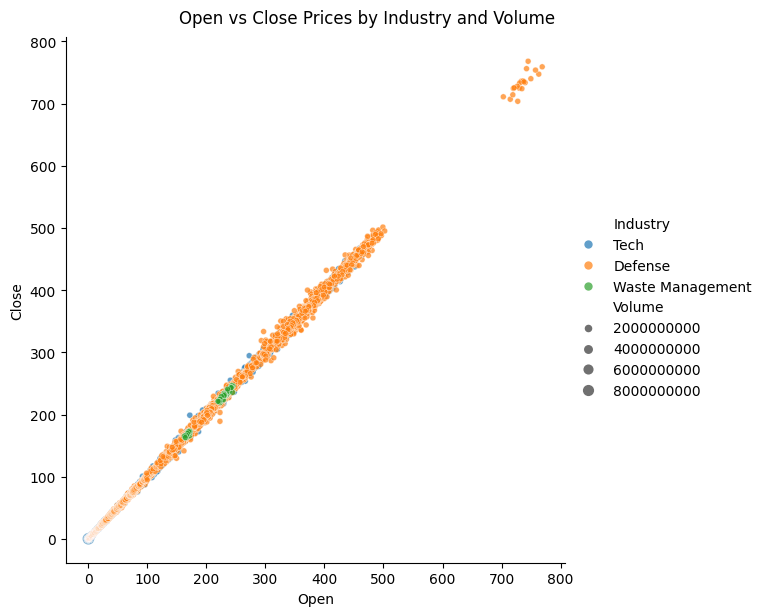

In [13]:
g = sns.relplot(
    data=stocks,
    x='Open',
    y='Close',
    hue='Industry',
    size='Volume',
    kind='scatter',
    alpha=0.7,
    height=6
)

g.fig.suptitle("Open vs Close Prices by Industry and Volume", y=1.02)
plt.show()


### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

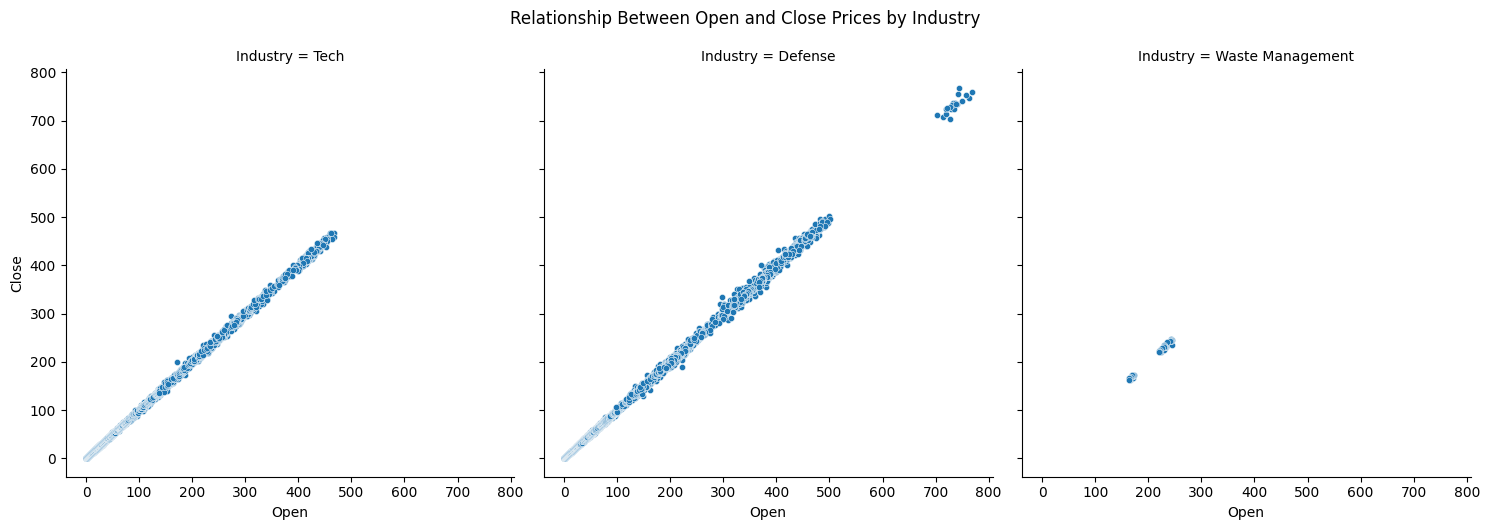

In [14]:
g = sns.relplot(
    data=stocks,
    x="Open",
    y="Close",
    col="Industry",
    col_wrap=3,
    kind="scatter",
    height=5,
    s=20
)

g.fig.suptitle("Relationship Between Open and Close Prices by Industry", y=1.05)

plt.show()